# Part 1 — Step 5: Data Splitting
**Two techniques:**
- **Technique 1:** Train / Validation / Test split (Dataset 1) — 70% / 15% / 15%
- **Technique 2:** K-Fold Cross Validation (Dataset 2) — k=5

Run after `agriculture_feature_engineering.ipynb`.

In [1]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    cross_validate, StratifiedKFold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import KBinsDiscretizer
import warnings, os
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Cell 2 : Load datasets ────────────────────────────────────────────────────
df1 = pd.read_csv('datasets/dataset1_clean_std.csv')   # Dataset 1 (clean, scaled)
df2 = pd.read_csv('datasets/dataset2_agriculture_genAI.csv')  # Dataset 2 (GenAI)

TARGET_COLS  = ['water_allocation_L_ha', 'fertilizer_N_kg_ha', 'fertilizer_P_kg_ha']
FEATURE_COLS = [c for c in df1.columns if c not in TARGET_COLS]

# Dataset 1
X1 = df1[FEATURE_COLS].values
y1 = df1[TARGET_COLS].values

# Dataset 2 — align columns, encode categoricals
df2_enc = pd.get_dummies(df2.drop(columns=['source'], errors='ignore'),
                         columns=['soil_type','crop_type','growth_stage'],
                         drop_first=True)
# Keep only columns present in Dataset 1
common_cols = [c for c in FEATURE_COLS if c in df2_enc.columns]
X2 = df2_enc[common_cols].fillna(0).values
y2 = df2[TARGET_COLS].values

print(f'Dataset 1  X:{X1.shape}  y:{y1.shape}')
print(f'Dataset 2  X:{X2.shape}  y:{y2.shape}')

Dataset 1  X:(1989, 17)  y:(1989, 3)
Dataset 2  X:(500, 16)  y:(500, 3)


---
## Technique 1 — Train / Validation / Test split (Dataset 1)

In [3]:
# ── Cell 3 : 70 / 15 / 15 split ──────────────────────────────────────────────
#
# Step 1: split into train (70%) and temp (30%)
# Step 2: split temp into val (50% of 30% = 15%) and test (50% of 30% = 15%)
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_temp, y_train, y_temp = train_test_split(
    X1, y1, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

total = len(X1)
print('Split summary (Dataset 1):')
print(f'  Training   : {len(X_train):>5} rows  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation : {len(X_val):>5} rows  ({len(X_val)/total*100:.1f}%)')
print(f'  Test       : {len(X_test):>5} rows  ({len(X_test)/total*100:.1f}%)')
print(f'  Total      : {total:>5} rows  (100%)')

Split summary (Dataset 1):
  Training   :  1392 rows  (70.0%)
  Validation :   298 rows  (15.0%)
  Test       :   299 rows  (15.0%)
  Total      :  1989 rows  (100%)


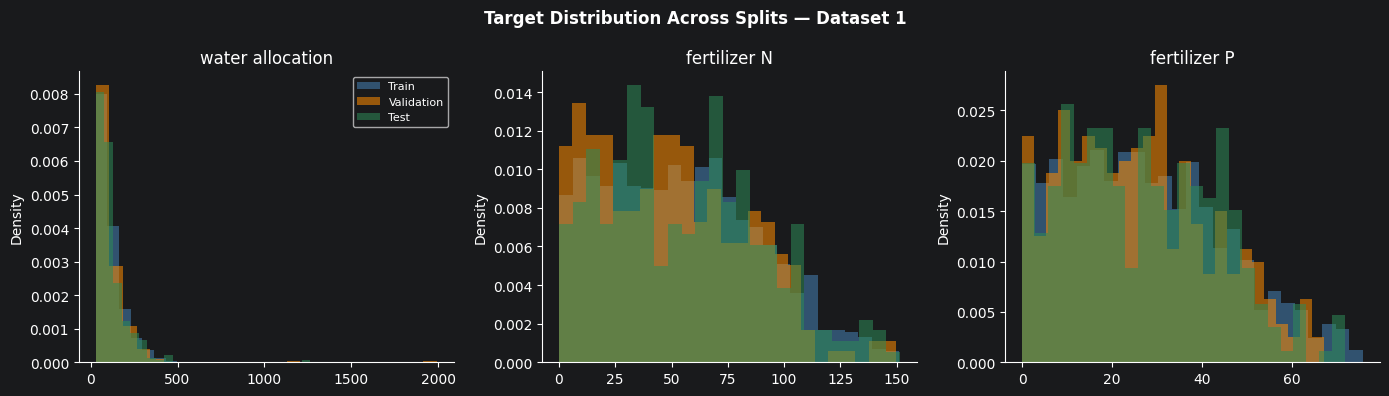

Distributions look consistent across splits — no data leakage detected.


In [4]:
# ── Cell 4 : Verify no data leakage — check target distributions ──────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Target Distribution Across Splits — Dataset 1', fontsize=12, fontweight='bold')

colors = {'Train':'steelblue','Validation':'darkorange','Test':'seagreen'}
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for ax, (col_idx, col) in zip(axes, enumerate(TARGET_COLS)):
    for split_name, y_split in splits.items():
        ax.hist(y_split[:, col_idx], bins=25, alpha=0.55,
                color=colors[split_name], label=split_name, density=True)
    ax.set_title(col.replace('_',' ').replace(' L ha','').replace(' kg ha',''))
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if col_idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('split_distributions.png', dpi=120)
plt.show()
print('Distributions look consistent across splits — no data leakage detected.')

---
## Technique 2 — K-Fold Cross Validation (Dataset 2)

In [5]:
# ── Cell 5 : K-Fold (k=5) cross validation on Dataset 2 ──────────────────────
#
# KFold divides Dataset 2 into 5 folds. In each iteration:
#   - 4 folds are used for training
#   - 1 fold is used for validation
# This gives 5 different validation scores — their mean is the generalisation estimate.
# ─────────────────────────────────────────────────────────────────────────────

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

print(f'K-Fold (k={K}) fold sizes on Dataset 2 ({len(X2)} rows):')
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X2)):
    print(f'  Fold {fold_idx+1}: train={len(train_idx)}  val={len(val_idx)}')

K-Fold (k=5) fold sizes on Dataset 2 (500 rows):
  Fold 1: train=400  val=100
  Fold 2: train=400  val=100
  Fold 3: train=400  val=100
  Fold 4: train=400  val=100
  Fold 5: train=400  val=100


In [6]:
# ── Cell 6 : Run cross_validate with a RandomForest (quick baseline) ──────────

rf_cv = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# cross_validate returns fit/score times + test scores per fold
cv_results = cross_validate(
    rf_cv, X2, y2,
    cv=kf,
    scoring='r2',
    return_train_score=True
)

print(f'Cross-validation R² scores per fold (Dataset 2):')
for i, (tr, te) in enumerate(
    zip(cv_results['train_score'], cv_results['test_score'])):
    print(f'  Fold {i+1}: train R²={tr:.4f}  val R²={te:.4f}')

print()
print(f'  Mean train R² : {cv_results["train_score"].mean():.4f} ± {cv_results["train_score"].std():.4f}')
print(f'  Mean val   R² : {cv_results["test_score"].mean():.4f}  ± {cv_results["test_score"].std():.4f}')

Cross-validation R² scores per fold (Dataset 2):
  Fold 1: train R²=0.9155  val R²=0.3759
  Fold 2: train R²=0.9093  val R²=0.3654
  Fold 3: train R²=0.9049  val R²=0.4174
  Fold 4: train R²=0.9146  val R²=0.4128
  Fold 5: train R²=0.9133  val R²=0.3847

  Mean train R² : 0.9115 ± 0.0039
  Mean val   R² : 0.3912  ± 0.0205


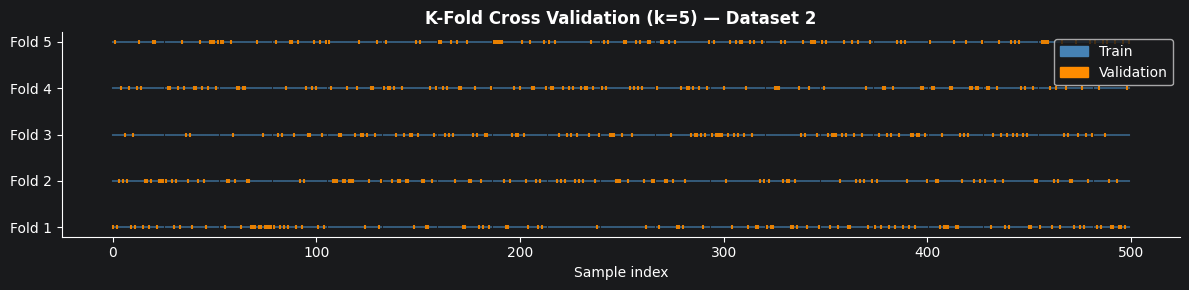

In [7]:
# ── Cell 7 : Visualise K-Fold split structure ─────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 3))
n_samples = len(X2)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X2)):
    # Train indices in blue
    ax.scatter(train_idx, [fold_idx + 1] * len(train_idx),
               c='steelblue', s=3, alpha=0.6, marker='|')
    # Val indices in orange
    ax.scatter(val_idx, [fold_idx + 1] * len(val_idx),
               c='darkorange', s=6, alpha=0.9, marker='|')

ax.set_yticks(range(1, K + 1))
ax.set_yticklabels([f'Fold {i}' for i in range(1, K+1)])
ax.set_xlabel('Sample index')
ax.set_title(f'K-Fold Cross Validation (k={K}) — Dataset 2', fontweight='bold')
train_patch = mpatches.Patch(color='steelblue',   label='Train')
val_patch   = mpatches.Patch(color='darkorange', label='Validation')
ax.legend(handles=[train_patch, val_patch])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('split_kfold_structure.png', dpi=120)
plt.show()

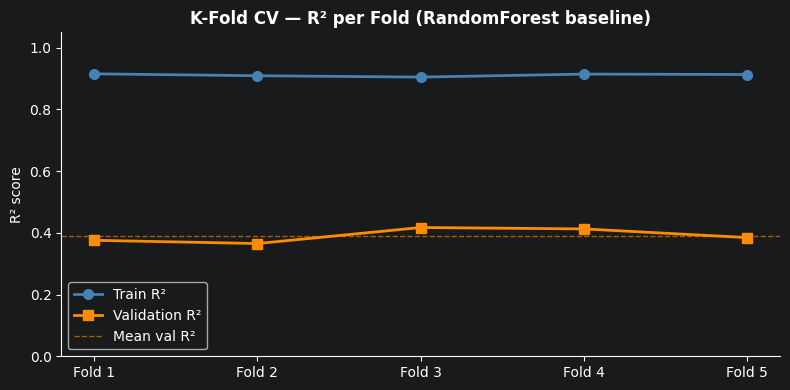

In [8]:
# ── Cell 8 : Visualise K-Fold R² scores per fold ─────────────────────────────

folds = range(1, K+1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(folds, cv_results['train_score'], 'o-', color='steelblue',
        linewidth=2, markersize=7, label='Train R²')
ax.plot(folds, cv_results['test_score'],  's-', color='darkorange',
        linewidth=2, markersize=7, label='Validation R²')
ax.axhline(cv_results['test_score'].mean(), color='darkorange',
           linestyle='--', linewidth=1, alpha=0.6, label='Mean val R²')
ax.set_xticks(list(folds))
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylabel('R² score')
ax.set_title('K-Fold CV — R² per Fold (RandomForest baseline)', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('split_kfold_scores.png', dpi=120)
plt.show()

In [9]:
# ── Cell 9 : Save split indices for reuse in training notebook ────────────────
import pickle, os
os.makedirs('splits', exist_ok=True)

split_data = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'feature_cols': FEATURE_COLS,
    'target_cols':  TARGET_COLS,
    'kfold_params': {'n_splits': K, 'shuffle': True, 'random_state': 42},
    'X2': X2, 'y2': y2
}

with open('splits/split_data.pkl', 'wb') as f:
    pickle.dump(split_data, f)

print('Saved: splits/split_data.pkl')
print()
print('=== SPLITTING SUMMARY ===')
print(f'  Technique 1 — Train/Val/Test  : {len(X_train)} / {len(X_val)} / {len(X_test)}')
print(f'  Technique 2 — K-Fold (k={K})   : mean val R² = {cv_results["test_score"].mean():.4f}')

Saved: splits/split_data.pkl

=== SPLITTING SUMMARY ===
  Technique 1 — Train/Val/Test  : 1392 / 298 / 299
  Technique 2 — K-Fold (k=5)   : mean val R² = 0.3912
